In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

df = sns.load_dataset("mpg")
print(df.shape)

(398, 9)


In [2]:
df = df.drop(columns=["name"])
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,usa
1,15.0,8,350.0,165.0,3693,11.5,70,usa
2,18.0,8,318.0,150.0,3436,11.0,70,usa
3,16.0,8,304.0,150.0,3433,12.0,70,usa
4,17.0,8,302.0,140.0,3449,10.5,70,usa


In [3]:
df["age"] = 82 - df["model_year"]
df[["model_year", "age"]].head()

,model_year,age
0,70,12
1,70,12
2,70,12
3,70,12
4,70,12


In [4]:
X = df.drop(columns=["mpg"])
y = df["mpg"]
print(X.shape, y.shape)

(398, 8) (398,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape, X_test.shape)

(318, 8) (80, 8)


In [8]:
num_cols = ["cylinders", "displacement", "horsepower", "weight", "acceleration", "age"]
cat_cols = ["origin"]

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

In [10]:
X_train_prep = preprocessor.fit_transform(X_train)
print(X_train_prep.shape)
print(X_train_prep[:3])

(318, 9)
[[ 1.52718818  1.0901965   1.26623169  0.55282624 -1.31933367  1.6966673
   0.          0.          1.        ]
 [-0.85051483 -0.92299623 -0.40792496 -0.99966729 -0.41318225  1.6966673
   0.          1.          0.        ]
 [-0.85051483 -0.98134964 -0.94797549 -1.1247723   0.92792185 -1.63897537
   0.          1.          0.        ]]


In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

lin_model = Pipeline([
    ("prep", preprocessor),
    ("model", LinearRegression())
])

lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)

print("MAE :", round(mean_absolute_error(y_test, y_pred), 2))
print("RMSE:", round(root_mean_squared_error(y_test, y_pred), 2))
print("R²  :", round(r2_score(y_test, y_pred), 3))

MAE : 2.29
RMSE: 2.89
R²  : 0.845


In [12]:
baseline_pred = np.full(len(y_test), y_train.mean())
print("MAE baseline :", round(mean_absolute_error(y_test, baseline_pred), 2))

MAE baseline : 5.96


In [13]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(n_estimators=300, random_state=42))
])

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("MAE :", round(mean_absolute_error(y_test, y_pred_rf), 2))
print("RMSE:", round(root_mean_squared_error(y_test, y_pred_rf), 2))
print("R²  :", round(r2_score(y_test, y_pred_rf), 3))

MAE : 1.58
RMSE: 2.17
R²  : 0.912


In [14]:
print("R² train :", round(rf_model.score(X_train, y_train), 3))
print("R² test  :", round(rf_model.score(X_test, y_test), 3))

R² train : 0.981
R² test  : 0.912


In [15]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring="r2")
print("Scores :", scores.round(3))
print("Moyenne:", scores.mean().round(3), "±", scores.std().round(3))

Scores : [0.873 0.85  0.845 0.783 0.872]
Moyenne: 0.844 ± 0.033


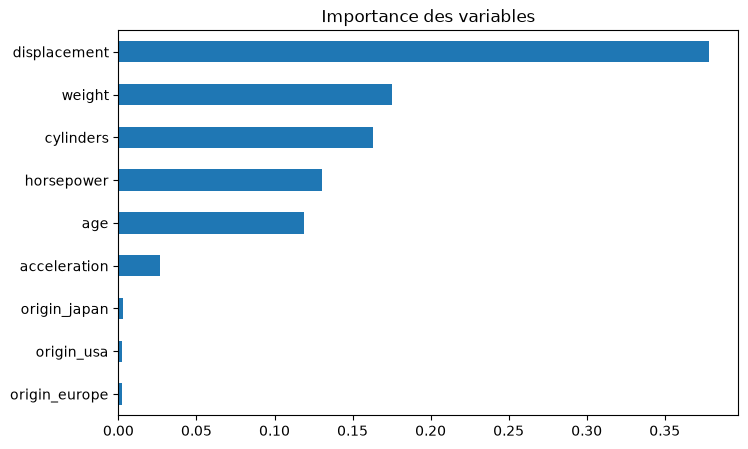

In [16]:
import matplotlib.pyplot as plt

feature_names = (num_cols + 
    list(rf_model.named_steps["prep"]
         .named_transformers_["cat"]
         .named_steps["encoder"]
         .get_feature_names_out(cat_cols)))

importances = rf_model.named_steps["model"].feature_importances_

imp = pd.Series(importances, index=feature_names).sort_values()
imp.plot(kind="barh", figsize=(8, 5))
plt.title("Importance des variables")
plt.show()

In [17]:
import joblib

joblib.dump(rf_model, "model.pkl")
print("Modèle sauvegardé")

Modèle sauvegardé


In [18]:
loaded = joblib.load("model.pkl")

exemple = pd.DataFrame([{
    "cylinders": 4,
    "displacement": 120.0,
    "horsepower": 90.0,
    "weight": 2400,
    "acceleration": 15.0,
    "model_year": 80,
    "origin": "japan",
    "age": 2
}])

print(round(loaded.predict(exemple)[0], 2), "mpg")

34.66 mpg
